In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.interpolate import CubicSpline

In [9]:
def complex_wave(x):
    return np.exp(-x**2) * (x**3 - 2*x) + 0.5*x / (1 + 10 * (x - 1.7)**2)
def make_grid(a,h,q,N):
    my_grid = [a+h*q**k for k in range(N)]
    return np.array(my_grid)


[-1.90000000e+00 -1.89870000e+00 -1.89738310e+00 -1.89604908e+00
 -1.89469772e+00 -1.89332879e+00 -1.89194206e+00 -1.89053731e+00
 -1.88911429e+00 -1.88767278e+00 -1.88621253e+00 -1.88473329e+00
 -1.88323482e+00 -1.88171688e+00 -1.88017919e+00 -1.87862152e+00
 -1.87704360e+00 -1.87544517e+00 -1.87382596e+00 -1.87218570e+00
 -1.87052411e+00 -1.86884092e+00 -1.86713585e+00 -1.86540862e+00
 -1.86365893e+00 -1.86188650e+00 -1.86009102e+00 -1.85827221e+00
 -1.85642975e+00 -1.85456333e+00 -1.85267266e+00 -1.85075740e+00
 -1.84881725e+00 -1.84685187e+00 -1.84486094e+00 -1.84284414e+00
 -1.84080111e+00 -1.83873153e+00 -1.83663504e+00 -1.83451129e+00
 -1.83235994e+00 -1.83018062e+00 -1.82797296e+00 -1.82573661e+00
 -1.82347119e+00 -1.82117631e+00 -1.81885161e+00 -1.81649668e+00
 -1.81411113e+00 -1.81169458e+00 -1.80924661e+00 -1.80676681e+00
 -1.80425478e+00 -1.80171010e+00 -1.79913233e+00 -1.79652105e+00
 -1.79387582e+00 -1.79119621e+00 -1.78848176e+00 -1.78573202e+00
 -1.78294654e+00 -1.78012

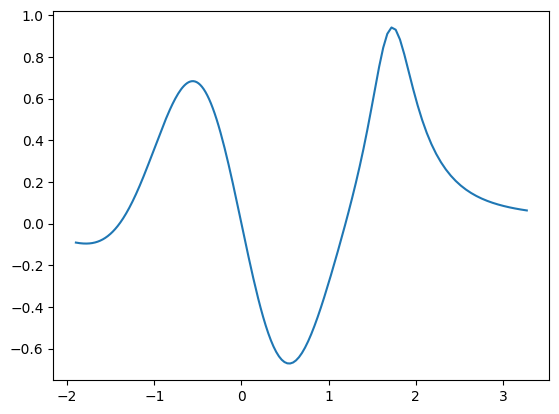

In [10]:
m_g = make_grid(-2,0.1,1.013,300+8)
nepreriv_grid = np.arange(m_g[0],m_g[-1],0.01)
print(m_g)
plt.plot(m_g,complex_wave(m_g))
#print(complex_wave(m_g))

kaif_function = complex_wave(m_g)

In [11]:
def make_noise_in_func(my_func:np.array):
    noise = np.abs(my_func)*1/10
    noise_arr = np.random.normal(0,noise)
    return my_func+noise_arr
kaif_function_noise = make_noise_in_func(kaif_function)

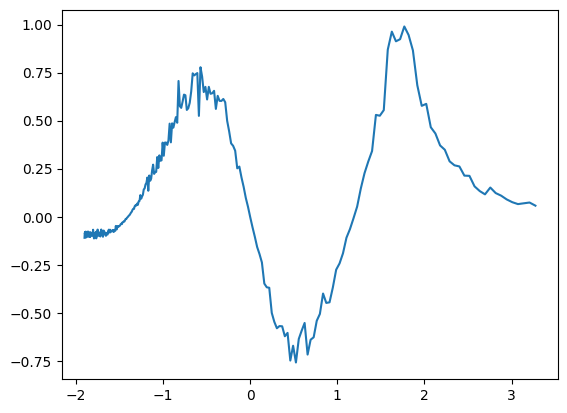

In [12]:
plt.plot(m_g,kaif_function_noise)

In [13]:
class Interpolator:
    def __init__(self,init_x:np.array,init_y:np.array):
        self.x:np.array = init_x
        self.y:np.array = init_y
    def evaluate_stairs(self,x:np.array):
        new_y = np.array([])
        #Ключевое условие что у нас будут совпадать начала координат по X
        iit = 0
        m_end = False
        for x_point in x:
            #print(iit,x_point)
            if not m_end:
                while x_point>=self.x[iit+1]:
                    #print(iit)
                    iit+=1
                    if iit == len(self.x)-1:
                        m_end = True
                        break
                if iit<(len(self.x)-1):
                    new_y = np.append(new_y,(self.y[iit] + self.y[iit+1])/2)
            else:
                new_y = np.append(new_y,new_y[-1])
        return new_y
    def evaluate_linear(self,x:np.array):
        new_y = np.array([])
        #Ключевое условие что у нас будут совпадать начала координат по X
        iit = 0
        m_end = False
        for x_point in x:
            if not m_end:
                while x_point>=self.x[iit+1]:
                        #print(iit)
                        iit+=1
                        if iit == len(self.x)-1:
                            #print(iit,len(self.x))
                            m_end = True
                            break
                if iit<len(self.x)-1:
                    print(self.x[iit:iit+1],self.y[iit:iit+1])
                    k = (self.y[iit+1] - self.y[iit])/(self.x[iit+1] - self.x[iit])
                    new_y = np.append(new_y,self.y[iit] + (x_point-self.x[iit])*k)
            else:
                k = (self.y[-1] - self.y[-2])/(self.x[-1]-self.x[-2])
                new_y = np.append(new_y,self.y[-2]+ (x_point-x[-1])*k)
        return new_y       




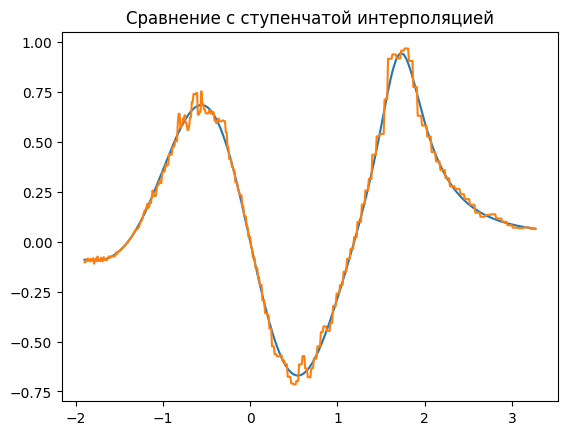

[-1.9] [-0.10976429]
[-1.89053731] [-0.1023951]
[-1.88017919] [-0.09397632]
[-1.87052411] [-0.09088498]
[-1.86009102] [-0.07714725]
[-1.8507574] [-0.08068944]
[-1.84080111] [-0.09471201]
[-1.83018062] [-0.09059292]
[-1.82117631] [-0.0883872]
[-1.81169458] [-0.09515263]
[-1.8017101] [-0.06786853]
[-1.79119621] [-0.11320812]
[-1.78012484] [-0.08616219]
[-1.77143775] [-0.07912978]
[-1.76240744] [-0.10223751]
[-1.75302035] [-0.08138175]
[-1.74326238] [-0.08747019]
[-1.73311888] [-0.09034969]
[-1.72257462] [-0.09178167]
[-1.71161377] [-0.09301826]
[-1.70021986] [-0.0925692]
[-1.69237492] [-0.09281761]
[-1.6802209] [-0.07224177]
[-1.6718526] [-0.08975474]
[-1.66326531] [-0.0819928]
[-1.6544533] [-0.09963061]
[-1.64080102] [-0.08900327]
[-1.63140115] [-0.07766661]
[-1.62175528] [-0.06746654]
[-1.611857] [-0.08194241]
[-1.60169968] [-0.08105056]
[-1.59127656] [-0.07525306]
[-1.58058068] [-0.07016663]
[-1.57512823] [-0.07641481]
[-1.56400976] [-0.07922758]
[-1.55260033] [-0.06852069]
[-1.540892

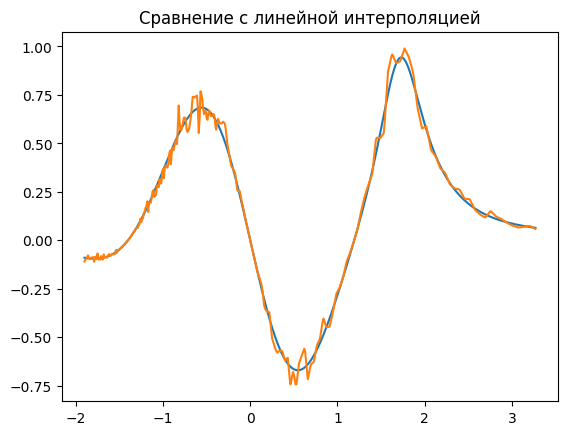

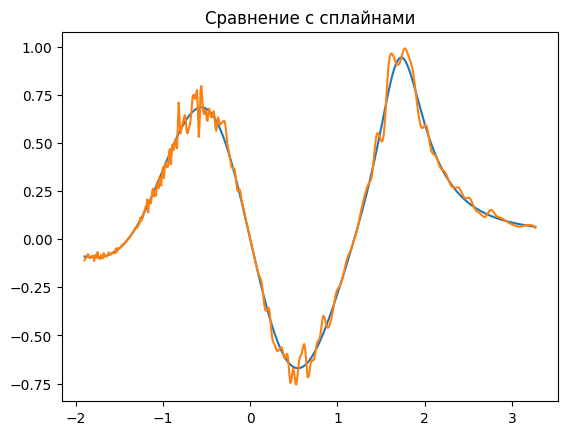

In [14]:
my_interp = Interpolator(m_g,kaif_function_noise)
plt.title("Сравнение с ступенчатой интерполяцией")
plt.plot(nepreriv_grid,complex_wave(nepreriv_grid))
plt.plot(nepreriv_grid,my_interp.evaluate_stairs(nepreriv_grid))
plt.show()
plt.title("Сравнение с линейной интерполяцией")
plt.plot(nepreriv_grid,complex_wave(nepreriv_grid))
plt.plot(nepreriv_grid,my_interp.evaluate_linear(nepreriv_grid))
plt.show()

plt.title("Сравнение с сплайнами")
cs = CubicSpline(m_g,kaif_function_noise,bc_type='not-a-knot')
plt.plot(nepreriv_grid,complex_wave(nepreriv_grid))
plt.plot(nepreriv_grid,cs(nepreriv_grid))
plt.show()


In [15]:
ten_percent = (nepreriv_grid[-1] - nepreriv_grid[0])*1/10
extrp_grid = np.arange(nepreriv_grid[0],nepreriv_grid[-1]+ten_percent,0.01)
print(len(nepreriv_grid))

518


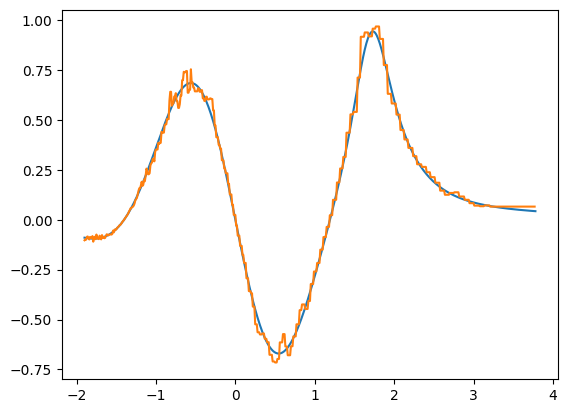

[-1.9] [-0.10976429]
[-1.89053731] [-0.1023951]
[-1.88017919] [-0.09397632]
[-1.87052411] [-0.09088498]
[-1.86009102] [-0.07714725]
[-1.8507574] [-0.08068944]
[-1.84080111] [-0.09471201]
[-1.83018062] [-0.09059292]
[-1.82117631] [-0.0883872]
[-1.81169458] [-0.09515263]
[-1.8017101] [-0.06786853]
[-1.79119621] [-0.11320812]
[-1.78012484] [-0.08616219]
[-1.77143775] [-0.07912978]
[-1.76240744] [-0.10223751]
[-1.75302035] [-0.08138175]
[-1.74326238] [-0.08747019]
[-1.73311888] [-0.09034969]
[-1.72257462] [-0.09178167]
[-1.71161377] [-0.09301826]
[-1.70021986] [-0.0925692]
[-1.69237492] [-0.09281761]
[-1.6802209] [-0.07224177]
[-1.6718526] [-0.08975474]
[-1.66326531] [-0.0819928]
[-1.6544533] [-0.09963061]
[-1.64080102] [-0.08900327]
[-1.63140115] [-0.07766661]
[-1.62175528] [-0.06746654]
[-1.611857] [-0.08194241]
[-1.60169968] [-0.08105056]
[-1.59127656] [-0.07525306]
[-1.58058068] [-0.07016663]
[-1.57512823] [-0.07641481]
[-1.56400976] [-0.07922758]
[-1.55260033] [-0.06852069]
[-1.540892

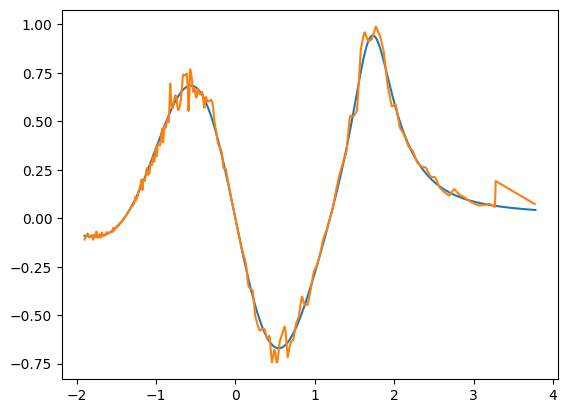

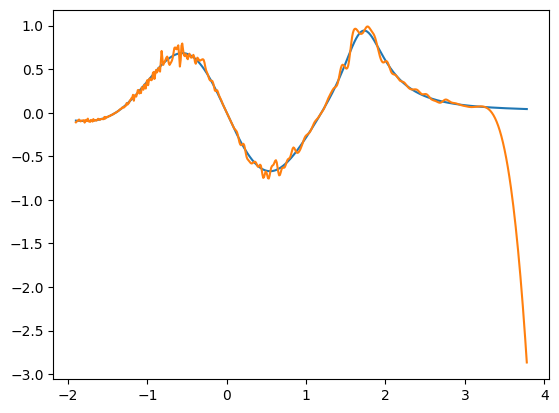

In [16]:
plt.plot(extrp_grid[:],complex_wave(extrp_grid))
plt.plot(extrp_grid[:-1],my_interp.evaluate_stairs(extrp_grid)[:])
plt.show()


plt.plot(extrp_grid[:],complex_wave(extrp_grid))
plt.plot(extrp_grid[:-1],my_interp.evaluate_linear(extrp_grid)[:])
plt.show()

plt.plot(extrp_grid[:],complex_wave(extrp_grid))
plt.plot(extrp_grid[:],cs(extrp_grid)[:])

PART 2

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error

R^2 = 0.053866109330195866
RMSE = 0.3238343751518677
VAR_pred = 0.005970475269412184, VAR_true = 0.11083917779941278


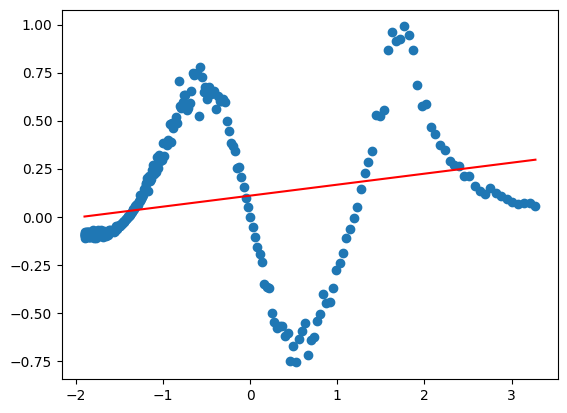

R^2 = 0.07332585181880613
RMSE = 0.32048681825057135
VAR_pred = 0.008127377127038047, VAR_true = 0.11083917779941278


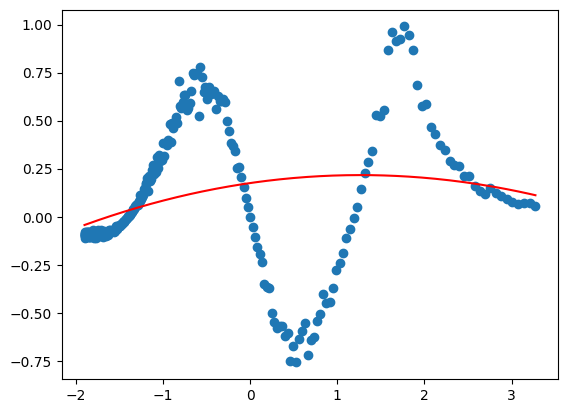

In [18]:
my_x = m_g
my_y = kaif_function_noise

my_x_shaped = my_x.reshape(-1,1)
model = LinearRegression()
model.fit(my_x_shaped, my_y)

# Предсказания
y_pred = model.predict(my_x_shaped)

print(f"R^2 = {r2_score(my_y,y_pred)}")
print(f"RMSE = {np.sqrt(mean_squared_error(my_y, y_pred))}")
print(f"VAR_pred = {np.var(y_pred)}, VAR_true = {np.var(my_y)}")



plt.scatter(my_x,my_y)
plt.plot(my_x,y_pred,color='r')
plt.show()

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_model.fit(my_x_shaped, my_y)
y_poly_pred = poly_model.predict(my_x_shaped)
print(f"R^2 = {r2_score(my_y,y_poly_pred)}")
print(f"RMSE = {np.sqrt(mean_squared_error(my_y, y_poly_pred))}")
print(f"VAR_pred = {np.var(y_poly_pred)}, VAR_true = {np.var(my_y)}")
plt.scatter(my_x,my_y)
plt.plot(my_x,y_poly_pred,color='r')